# Predicción Salarial en Tecnología v4
## Modelos avanzados, embeddings semánticos y análisis de sesgos

Objetivo: predecir salarios con la data disponible, comparar modelos y dejar un notebook listo para paper científico.

Novedades:
- Embeddings semánticos para `job_title`, `primary_skill`, `secondary_skill`
- XGBoost / LightGBM / CatBoost
- Optuna y Bayesian Optimization
- Ensamble (Ridge + HistGradientBoosting + CatBoost)
- Análisis de sesgos (género, región, educación)
- Interpretabilidad: SHAP, PDP, LIME

## Diagnóstico rápido de v3 (por qué algunos modelos no se adaptan)
- El target está dominado por país/moneda (la importancia muestra `country_target` como variable principal).
- La señal es casi lineal con experiencia/país: modelos lineales quedan fuertes, árboles complejos no siempre agregan valor.
- Alta cardinalidad y ruido en `job_title`/skills: target encoding pierde semántica y puede introducir sesgo hacia promedios.
- Outlier clipping + log1p reducen varianza: ayuda a estabilidad, pero reduce señal para colas extremas.
- Evaluación CV con embedding ausente hace que modelos no capten relaciones semánticas en títulos/skills.

Esta versión agrega embeddings semánticos, boosting avanzado y optimización Bayesiana para mejorar la adaptación.

In [12]:
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor
from sklearn.inspection import PartialDependenceDisplay

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)
SEED = 42
np.random.seed(SEED)

# Imports opcionales (se activan si están instalados)
try:
    import optuna
except Exception:
    optuna = None

try:
    from skopt import BayesSearchCV
except Exception:
    BayesSearchCV = None

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None

try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None

try:
    import shap
except Exception:
    shap = None

try:
    from lime.lime_tabular import LimeTabularExplainer
except Exception:
    LimeTabularExplainer = None

try:
    from sentence_transformers import SentenceTransformer
except Exception:
    SentenceTransformer = None


## 1) Carga y diagnóstico inicial
Revisamos tipos de datos, nulos y columnas disponibles.

### Detalle de preprocesamiento (resumen)
En esta sección se validan tipos de datos, cobertura de variables y ausencia de nulos. Esto permite justificar que el pipeline no requiere imputación agresiva y que el modelado puede centrarse en transformación y normalización.

In [13]:
DATA_PATH = 'tech_jobs_salaries.xlsx'

if DATA_PATH.lower().endswith('.xlsx'):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
display(df.head())
display(df.dtypes)
missing = df.isna().mean().sort_values(ascending=False)
print('\nTop missingness:')
display(missing.head(15))

Dataset shape: (200000, 17)


,job_title,company_size,employment_type,experience_level,years_experience,education_level,country,salary_local_currency,currency,remote_type,primary_skill,secondary_skill,work_hours_per_week,job_satisfaction_score,company_rating,age,gender
0,DevOps Engineer,SME,Full-time,Entry,3,Self-taught,India,1087489,INR,Onsite,SQL,Java,35,2.7,3.3,22,Female
1,Mobile App Developer,SME,Full-time,Lead,14,Bachelor,Japan,25198412,USD,Onsite,Docker,TensorFlow,57,2.8,3.9,51,Male
2,Cloud Engineer,Startup,Freelance,Senior,14,Self-taught,India,2579715,INR,Onsite,Kubernetes,C++,52,3.2,4.2,44,Female
3,Cybersecurity Analyst,Startup,Full-time,Entry,3,Diploma,India,949111,INR,Hybrid,NoSQL,Docker,40,3.4,3.3,38,Male
4,Backend Developer,SME,Contract,Lead,10,Self-taught,Japan,25195363,USD,Onsite,Linux,TensorFlow,56,2.8,4.5,54,Male


job_title                     str
company_size                  str
employment_type               str
experience_level              str
years_experience            int64
education_level               str
country                       str
salary_local_currency       int64
currency                      str
remote_type                   str
primary_skill                 str
secondary_skill               str
work_hours_per_week         int64
job_satisfaction_score    float64
company_rating            float64
age                         int64
gender                        str
dtype: object


Top missingness:


job_title                 0.0
company_size              0.0
employment_type           0.0
experience_level          0.0
years_experience          0.0
education_level           0.0
country                   0.0
salary_local_currency     0.0
currency                  0.0
remote_type               0.0
primary_skill             0.0
secondary_skill           0.0
work_hours_per_week       0.0
job_satisfaction_score    0.0
company_rating            0.0
dtype: float64

In [ ]:
# Visualización de missingness (para paper)
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)
missing = df.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=missing.values[:10], y=missing.index[:10], color='#4C78A8')
plt.title('Porcentaje de missingness (top 10)')
plt.xlabel('Proporción de nulos')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'fig_missingness.png'), dpi=300, bbox_inches='tight')
plt.show()

## 2) Conversión a USD y target
Se corrige la moneda esperada por país y se transforma el target con log1p para estabilizar varianza.

### Detalle de preprocesamiento: normalización del target
- Corrección de moneda por país para homogeneizar el salario en USD.
- Clipping por IQR para limitar outliers extremos.
- Transformación $\log(1 + x)$ para estabilizar varianza y reducir heterocedasticidad.

In [14]:
work_df = df.copy()

country_currency_map = {
    'USA': 'USD', 'India': 'INR', 'UK': 'GBP', 'Germany': 'EUR',
    'France': 'EUR', 'Netherlands': 'EUR', 'Canada': 'CAD', 'Australia': 'AUD',
    'Japan': 'JPY', 'Singapore': 'SGD'
}
currency_to_usd = {
    'USD': 1.0, 'INR': 0.012, 'EUR': 1.08, 'GBP': 1.27,
    'CAD': 0.73, 'AUD': 0.66, 'JPY': 0.0067, 'SGD': 0.74
}

work_df['currency_corrected'] = work_df['country'].map(country_currency_map)
work_df['currency_corrected'] = work_df['currency_corrected'].fillna(work_df.get('currency', 'USD'))
work_df['currency_rate'] = work_df['currency_corrected'].map(currency_to_usd).fillna(1.0)
work_df['salary_usd'] = work_df['salary_local_currency'] * work_df['currency_rate']

q1 = work_df['salary_usd'].quantile(0.25)
q3 = work_df['salary_usd'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
work_df['salary_usd_capped'] = work_df['salary_usd'].clip(lower_bound, upper_bound)
work_df['salary_log'] = np.log1p(work_df['salary_usd_capped'])

print(work_df['salary_usd'].describe().round(0))
print('\nTarget (log1p) stats:')
print(work_df['salary_log'].describe())

count    200000.0
mean     105362.0
std       59653.0
min        3365.0
25%       61703.0
50%       95369.0
75%      140510.0
max      323906.0
Name: salary_usd, dtype: float64

Target (log1p) stats:
count    200000.000000
mean         11.367707
std           0.695667
min           8.121346
25%          11.030099
50%          11.465518
75%          11.853041
max          12.463509
Name: salary_log, dtype: float64


In [ ]:
# Distribución del target y clipping
fig_dir = 'figures'
os.makedirs(fig_dir, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(work_df['salary_usd'], bins=50, color='#4C78A8', alpha=0.7)
axes[0].set_title('Distribución salario USD (raw)')
axes[0].set_xlabel('USD')
axes[0].set_ylabel('Frecuencia')
axes[1].hist(work_df['salary_log'], bins=50, color='#F58518', alpha=0.7)
axes[1].set_title('Distribución salario USD (log1p)')
axes[1].set_xlabel('log(USD)')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'fig_target_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

## 3) Feature engineering y columnas clave

### Detalle de preprocesamiento: ingeniería de variables
Se transforman variables ordinales (experiencia, educación, tamaño, modalidad) y se crean interacciones para capturar no linealidades suaves sin perder interpretabilidad.

In [15]:
exp_map = {'Entry': 0, 'Mid': 1, 'Senior': 2, 'Lead': 3}
edu_map = {'Self-taught': 0, 'Diploma': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
size_map = {'Startup': 0, 'SME': 1, 'Mid-size': 2, 'Enterprise': 3}
remote_map = {'Onsite': 0, 'Hybrid': 1, 'Remote': 2}
emp_map = {'Freelance': 0, 'Contract': 1, 'Full-time': 2}

work_df['experience_num'] = work_df['experience_level'].map(exp_map)
work_df['education_num'] = work_df['education_level'].map(edu_map)
work_df['company_size_num'] = work_df['company_size'].map(size_map)
work_df['remote_num'] = work_df['remote_type'].map(remote_map)
work_df['employment_num'] = work_df['employment_type'].map(emp_map)

work_df['exp_x_edu'] = work_df['experience_num'] * work_df['education_num']
work_df['exp_x_years'] = work_df['experience_num'] * work_df['years_experience']
work_df['years_x_edu'] = work_df['years_experience'] * work_df['education_num']

work_df['productivity_score'] = work_df['job_satisfaction_score'] * work_df['company_rating']
work_df['hours_deviation'] = work_df['work_hours_per_week'] - 40
work_df['experience_per_age'] = work_df['years_experience'] / work_df['age']

high_demand_roles = ['data scientist', 'ml engineer', 'ai researcher', 'data engineer', 'software engineer']
work_df['is_high_demand'] = work_df['job_title'].str.lower().fillna('').apply(
    lambda x: int(any(role in x for role in high_demand_roles))
)
work_df['is_senior_plus'] = (work_df['experience_level'].isin(['Senior', 'Lead'])).astype(int)
work_df['is_full_time'] = (work_df['employment_type'] == 'Full-time').astype(int)
work_df['same_skills'] = (work_df['primary_skill'] == work_df['secondary_skill']).astype(int)

region_map = {
    'USA': 'North America', 'Canada': 'North America',
    'UK': 'Europe', 'Germany': 'Europe', 'France': 'Europe', 'Netherlands': 'Europe',
    'India': 'Asia', 'Japan': 'Asia', 'Singapore': 'Asia',
    'Australia': 'Oceania'
}
work_df['region'] = work_df['country'].map(region_map).fillna('Other')

print('Columnas disponibles:')
print(work_df.columns.tolist())

Columnas disponibles:
['job_title', 'company_size', 'employment_type', 'experience_level', 'years_experience', 'education_level', 'country', 'salary_local_currency', 'currency', 'remote_type', 'primary_skill', 'secondary_skill', 'work_hours_per_week', 'job_satisfaction_score', 'company_rating', 'age', 'gender', 'currency_corrected', 'currency_rate', 'salary_usd', 'salary_usd_capped', 'salary_log', 'experience_num', 'education_num', 'company_size_num', 'remote_num', 'employment_num', 'exp_x_edu', 'exp_x_years', 'years_x_edu', 'productivity_score', 'hours_deviation', 'experience_per_age', 'is_high_demand', 'is_senior_plus', 'is_full_time', 'same_skills', 'region']


## 4) Embeddings semánticos para títulos y skills
Se crea un campo de texto combinado y se transforma con SentenceTransformers.

In [16]:
class TextEmbeddingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name='all-MiniLM-L6-v2', cache_path=None):
        self.model_name = model_name
        self.cache_path = cache_path
        self.model_ = None

    def fit(self, X, y=None):
        if SentenceTransformer is None:
            raise ImportError('sentence-transformers no está instalado.')
        self.model_ = SentenceTransformer(self.model_name)
        return self

    def transform(self, X):
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        texts = [' | '.join([str(v) for v in row]) for row in X]
        embeddings = self.model_.encode(texts, show_progress_bar=True, normalize_embeddings=True)
        return embeddings


## 5) Selección de features y split

In [17]:
num_features = [
    'years_experience', 'work_hours_per_week', 'job_satisfaction_score',
    'company_rating', 'age',
    'experience_num', 'education_num', 'company_size_num', 'remote_num', 'employment_num',
    'exp_x_edu', 'exp_x_years', 'years_x_edu',
    'productivity_score', 'hours_deviation', 'experience_per_age',
    'is_high_demand', 'is_senior_plus', 'is_full_time', 'same_skills'
]

cat_low = [
    'company_size', 'employment_type', 'experience_level',
    'education_level', 'remote_type', 'gender', 'region'
]

cat_high = ['country']
text_cols = ['job_title', 'primary_skill', 'secondary_skill']

all_features = num_features + cat_low + cat_high + text_cols
missing_cols = [c for c in all_features if c not in work_df.columns]
if missing_cols:
    print(f'Columnas faltantes (se omiten): {missing_cols}')
    all_features = [c for c in all_features if c in work_df.columns]
    text_cols = [c for c in text_cols if c in all_features]

X = work_df[all_features].copy()
y = work_df['salary_log'].astype(np.float32)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=work_df['region']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED
)

print(f'Split: Train={X_train.shape}, Val={X_val.shape}, Test={X_test.shape}')

Split: Train=(128000, 31), Val=(32000, 31), Test=(40000, 31)


## 6) Preprocesamiento con embeddings

### Detalle de preprocesamiento: escalado e embeddings
- Numéricas: imputación mediana + estandarización.
- Categóricas: one-hot para baja/alta cardinalidad.
- Texto: embeddings semánticos con `SentenceTransformer` para captar similitud semántica.

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_low_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

categorical_high_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

text_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('embed', TextEmbeddingTransformer(cache_path=None))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, [c for c in num_features if c in all_features]),
        ('cat_low', categorical_low_transformer, [c for c in cat_low if c in all_features]),
        ('cat_high', categorical_high_transformer, [c for c in cat_high if c in all_features]),
        ('text', text_transformer, [c for c in text_cols if c in all_features])
    ],
    remainder='drop'
)

print('Preprocesador listo.')

Preprocesador listo.


## 7) Métricas

In [19]:
def compute_metrics(y_true, y_pred, prefix=''):
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_log = mean_absolute_error(y_true, y_pred)
    medae_log = median_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    y_true_usd = np.expm1(y_true)
    y_pred_usd = np.expm1(y_pred)

    rmse_usd = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))
    mae_usd = mean_absolute_error(y_true_usd, y_pred_usd)
    medae_usd = median_absolute_error(y_true_usd, y_pred_usd)
    mask = y_true_usd > 0
    mape = float(np.mean(np.abs((y_true_usd[mask] - y_pred_usd[mask]) / y_true_usd[mask])) * 100)

    return {
        f'{prefix}RMSE_log': rmse_log,
        f'{prefix}MAE_log': mae_log,
        f'{prefix}MedAE_log': medae_log,
        f'{prefix}R2': r2,
        f'{prefix}RMSE_USD': rmse_usd,
        f'{prefix}MAE_USD': mae_usd,
        f'{prefix}MedAE_USD': medae_usd,
        f'{prefix}MAPE': mape
    }


## 8) Modelos base + nuevos modelos

In [20]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_depth=10, learning_rate=0.1, max_iter=300, random_state=SEED),
}
if XGBRegressor is not None:
    models['XGBoost'] = XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, n_jobs=-1
    )
if LGBMRegressor is not None:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=500, num_leaves=64, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=SEED
    )
if CatBoostRegressor is not None:
    models['CatBoost'] = CatBoostRegressor(
        depth=8, learning_rate=0.05, iterations=600, loss_function='RMSE',
        verbose=False, random_seed=SEED
    )

print('Modelos configurados:', list(models.keys()))

Modelos configurados: ['Ridge', 'HistGradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


## 9) Validación cruzada rápida

In [21]:
def evaluate_model_cv(name, model, X, y, cv=5):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    kfold = KFold(n_splits=cv, shuffle=True, random_state=SEED)
    rmse_scores = -cross_val_score(pipeline, X, y, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
    r2_scores = cross_val_score(pipeline, X, y, cv=kfold, scoring='r2', n_jobs=-1)
    mae_scores = -cross_val_score(pipeline, X, y, cv=kfold, scoring='neg_mean_absolute_error', n_jobs=-1)
    return {
        'Modelo': name,
        'RMSE_mean': rmse_scores.mean(),
        'RMSE_std': rmse_scores.std(),
        'MAE_mean': mae_scores.mean(),
        'MAE_std': mae_scores.std(),
        'R2_mean': r2_scores.mean(),
        'R2_std': r2_scores.std()
    }

cv_results = []
for name, model in models.items():
    print(f'Evaluando {name}...')
    cv_results.append(evaluate_model_cv(name, model, X_train_full, y_train_full))

cv_df = pd.DataFrame(cv_results).sort_values('RMSE_mean').reset_index(drop=True)
display(cv_df.round(4))

Evaluando Ridge...


Batches: 100%|██████████| 1000/1000 [00:18<00:00, 55.18it/s]


Evaluando HistGradientBoosting...


Batches: 100%|██████████| 1000/1000 [00:16<00:00, 59.92it/s]


Evaluando XGBoost...


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.415968 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98805
[LightGBM] [Info] Number of data points in the train set: 128000, number of used features: 441
[LightGBM] [Info] Start training from score 11.365996
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.334895 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98805
[LightGBM] [Info] Number of data points in the train set: 128000, number of used features: 441
[LightGBM] [Info] Start training from score 11.368143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.369883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98805
[LightGBM] [Info] Number of data points in the train set: 128000, number of used features: 441
[LightGBM] [Info

Batches: 100%|██████████| 1000/1000 [00:13<00:00, 76.88it/s]


Evaluando CatBoost...


Batches: 100%|██████████| 1000/1000 [00:17<00:00, 55.56it/s]


,Modelo,RMSE_mean,RMSE_std,MAE_mean,MAE_std,R2_mean,R2_std
0,Ridge,0.3071,0.0017,0.2535,0.0011,0.8052,0.0021
1,HistGradientBoosting,0.3077,0.0018,0.2538,0.0011,0.8044,0.0020
2,CatBoost,0.3083,0.0018,0.2542,0.0012,0.8037,0.0022
3,XGBoost,0.3096,0.0017,0.2548,0.0011,0.8020,0.0022
4,LightGBM,0.3103,0.0019,0.2551,0.0012,0.8011,0.0021


## 10) Optuna (Bayesian) para XGBoost/CatBoost
Se busca mejorar hiperparámetros con TPE (Bayesiana).

In [22]:
def optuna_objective(trial, model_name):
    params = {}
    if model_name == 'XGBoost' and XGBRegressor is not None:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': SEED,
            'n_jobs': -1
        }
        model = XGBRegressor(**params)
    elif model_name == 'CatBoost' and CatBoostRegressor is not None:
        params = {
            'depth': trial.suggest_int('depth', 4, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'iterations': trial.suggest_int('iterations', 300, 900),
            'loss_function': 'RMSE',
            'verbose': False,
            'random_seed': SEED
        }
        model = CatBoostRegressor(**params)
    else:
        return 1e9

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    kfold = KFold(n_splits=3, shuffle=True, random_state=SEED)
    rmse_scores = -cross_val_score(pipeline, X_train_full, y_train_full, cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return rmse_scores.mean()

optuna_results = []
if optuna is not None:
    for name in ['XGBoost', 'CatBoost']:
        if name in models:
            print(f'Optuna para {name}...')
            study = optuna.create_study(direction='minimize')
            study.optimize(lambda trial: optuna_objective(trial, name), n_trials=25)
            best_params = study.best_params
            optuna_results.append({'Modelo': name, 'best_params': best_params, 'best_rmse': study.best_value})

display(pd.DataFrame(optuna_results))

[I 2026-05-17 20:22:54,291] A new study created in memory with name: no-name-6c2dc4c2-5c7c-4dd4-bb7a-753ac2f9cd66


Optuna para XGBoost...


Batches: 100%|██████████| 1667/1667 [00:18<00:00, 88.80it/s] 
[I 2026-05-17 20:26:38,823] Trial 0 finished with value: 0.309264600276947 and parameters: {'n_estimators': 449, 'max_depth': 8, 'learning_rate': 0.011126084155515047, 'subsample': 0.6837758157072884, 'colsample_bytree': 0.6165948706706517}. Best is trial 0 with value: 0.309264600276947.
Batches: 100%|██████████| 1667/1667 [00:17<00:00, 93.09it/s] 
[I 2026-05-17 20:30:09,504] Trial 1 finished with value: 0.3226284583409627 and parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.10420597435302131, 'subsample': 0.7905425772257644, 'colsample_bytree': 0.6738859901741996}. Best is trial 0 with value: 0.309264600276947.
Batches: 100%|██████████| 1667/1667 [00:17<00:00, 92.96it/s] 
[I 2026-05-17 20:31:54,670] Trial 2 finished with value: 0.3072623014450073 and parameters: {'n_estimators': 559, 'max_depth': 3, 'learning_rate': 0.03623326829137119, 'subsample': 0.7595204974536994, 'colsample_bytree': 0.8496584850968

Optuna para CatBoost...


Batches: 100%|██████████| 1667/1667 [00:19<00:00, 86.23it/s]
[I 2026-05-17 21:21:52,154] Trial 0 finished with value: 0.3076257871741463 and parameters: {'depth': 6, 'learning_rate': 0.04882565187791805, 'iterations': 609}. Best is trial 0 with value: 0.3076257871741463.
Batches: 100%|██████████| 1667/1667 [00:18<00:00, 90.69it/s] 
[I 2026-05-17 21:24:30,386] Trial 1 finished with value: 0.3099782532169329 and parameters: {'depth': 6, 'learning_rate': 0.10199412199240711, 'iterations': 841}. Best is trial 0 with value: 0.3076257871741463.
Batches: 100%|██████████| 1667/1667 [00:19<00:00, 85.49it/s] 
[I 2026-05-17 21:26:16,024] Trial 2 finished with value: 0.3070648679908252 and parameters: {'depth': 4, 'learning_rate': 0.03533644070418739, 'iterations': 622}. Best is trial 2 with value: 0.3070648679908252.
Batches: 100%|██████████| 1667/1667 [00:19<00:00, 85.09it/s] 
[I 2026-05-17 21:28:06,593] Trial 3 finished with value: 0.30890350633350644 and parameters: {'depth': 4, 'learning_rate

,Modelo,best_params,best_rmse
0,XGBoost,"{'n_estimators': 597, 'max_depth': 3, 'learnin...",0.307060
1,CatBoost,"{'depth': 4, 'learning_rate': 0.01773641679002...",0.306963


## 11) Bayesian Optimization (skopt) para Ridge/HistGB

In [23]:
bayes_results = []
if BayesSearchCV is not None:
    ridge_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', Ridge())])
    ridge_search = BayesSearchCV(
        ridge_pipe,
        search_spaces={'model__alpha': (1e-3, 100.0, 'log-uniform')},
        n_iter=20,
        cv=3,
        scoring='neg_root_mean_squared_error',
        random_state=SEED
    )
    ridge_search.fit(X_train_full, y_train_full)
    bayes_results.append({'Modelo': 'Ridge', 'best_params': ridge_search.best_params_})

    hist_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', HistGradientBoostingRegressor(random_state=SEED))])
    hist_search = BayesSearchCV(
        hist_pipe,
        search_spaces={
            'model__max_depth': (4, 12),
            'model__learning_rate': (0.01, 0.2, 'log-uniform'),
            'model__max_iter': (200, 600)
        },
        n_iter=20,
        cv=3,
        scoring='neg_root_mean_squared_error',
        random_state=SEED
    )
    hist_search.fit(X_train_full, y_train_full)
    bayes_results.append({'Modelo': 'HistGradientBoosting', 'best_params': hist_search.best_params_})

display(pd.DataFrame(bayes_results))

Batches: 100%|██████████| 5000/5000 [00:24<00:00, 207.53it/s]


,Modelo,best_params
0,Ridge,{'model__alpha': 59.894912052679324}
1,HistGradientBoosting,"{'model__learning_rate': 0.01816320661249906, ..."


## 12) Ensamble (Ridge + HistGradientBoosting + CatBoost)

In [24]:
stacking_models = []
stacking_models.append(('ridge', Ridge(alpha=1.0)))
stacking_models.append(('histgb', HistGradientBoostingRegressor(max_depth=10, learning_rate=0.1, max_iter=300, random_state=SEED)))
if CatBoostRegressor is not None:
    stacking_models.append(('cat', CatBoostRegressor(depth=8, learning_rate=0.05, iterations=600, loss_function='RMSE', verbose=False, random_seed=SEED)))

stacking_model = StackingRegressor(
    estimators=stacking_models,
    final_estimator=Ridge(alpha=0.5),
    passthrough=True
)

models['Stacking'] = stacking_model
print('Ensamble configurado.')

Ensamble configurado.


## 13) Evaluación final en test

In [25]:
final_results = []
trained_pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train_full, y_train_full)
    trained_pipelines[name] = pipe
    y_pred_test = pipe.predict(X_test)
    m = compute_metrics(y_test, y_pred_test, prefix='test_')
    m['Modelo'] = name
    final_results.append(m)
    print(f"{name}: R2={m['test_R2']:.4f}, RMSE=${m['test_RMSE_USD']:,.0f}, MAPE={m['test_MAPE']:.2f}%")

final_df = pd.DataFrame(final_results).sort_values('test_RMSE_log').reset_index(drop=True)
display(final_df.round(4))

Batches: 100%|██████████| 1250/1250 [00:05<00:00, 208.66it/s]


Ridge: R2=0.8075, RMSE=$29,758, MAPE=26.72%


Batches: 100%|██████████| 1250/1250 [00:05<00:00, 211.18it/s]


HistGradientBoosting: R2=0.8070, RMSE=$29,773, MAPE=26.77%


Batches: 100%|██████████| 1250/1250 [00:05<00:00, 209.23it/s]


...

Batches: 100%|██████████| 1250/1250 [00:06<00:00, 202.18it/s]


CatBoost: R2=0.8063, RMSE=$29,792, MAPE=26.79%


Batches: 100%|██████████| 1250/1250 [00:05<00:00, 211.27it/s]


Stacking: R2=0.8075, RMSE=$29,748, MAPE=26.72%


,test_RMSE_log,test_MAE_log,test_MedAE_log,test_R2,test_RMSE_USD,test_MAE_USD,test_MedAE_USD,test_MAPE,Modelo
0,0.3047,0.2518,0.2365,0.8075,29747.9943,23686.7514,19755.8106,26.7165,Stacking
1,0.3048,0.2518,0.2365,0.8075,29757.8974,23688.9768,19779.7210,26.7190,Ridge
2,0.3052,0.2521,0.2361,0.8070,29773.3621,23719.4980,19739.7323,26.7715,HistGradientBoosting
3,0.3057,0.2524,0.2369,0.8063,29792.3031,23728.2029,19748.3141,26.7873,CatBoost
4,0.3067,0.2529,0.2372,0.8050,29872.3385,23780.3555,19785.1211,26.8526,XGBoost
5,0.3074,0.2532,0.2381,0.8042,29898.9397,23798.7622,19796.1194,26.8880,LightGBM


## 14) Visualización de resultados (para paper)
Gráficos para comparar modelos, visualizar errores y documentar hallazgos clave.

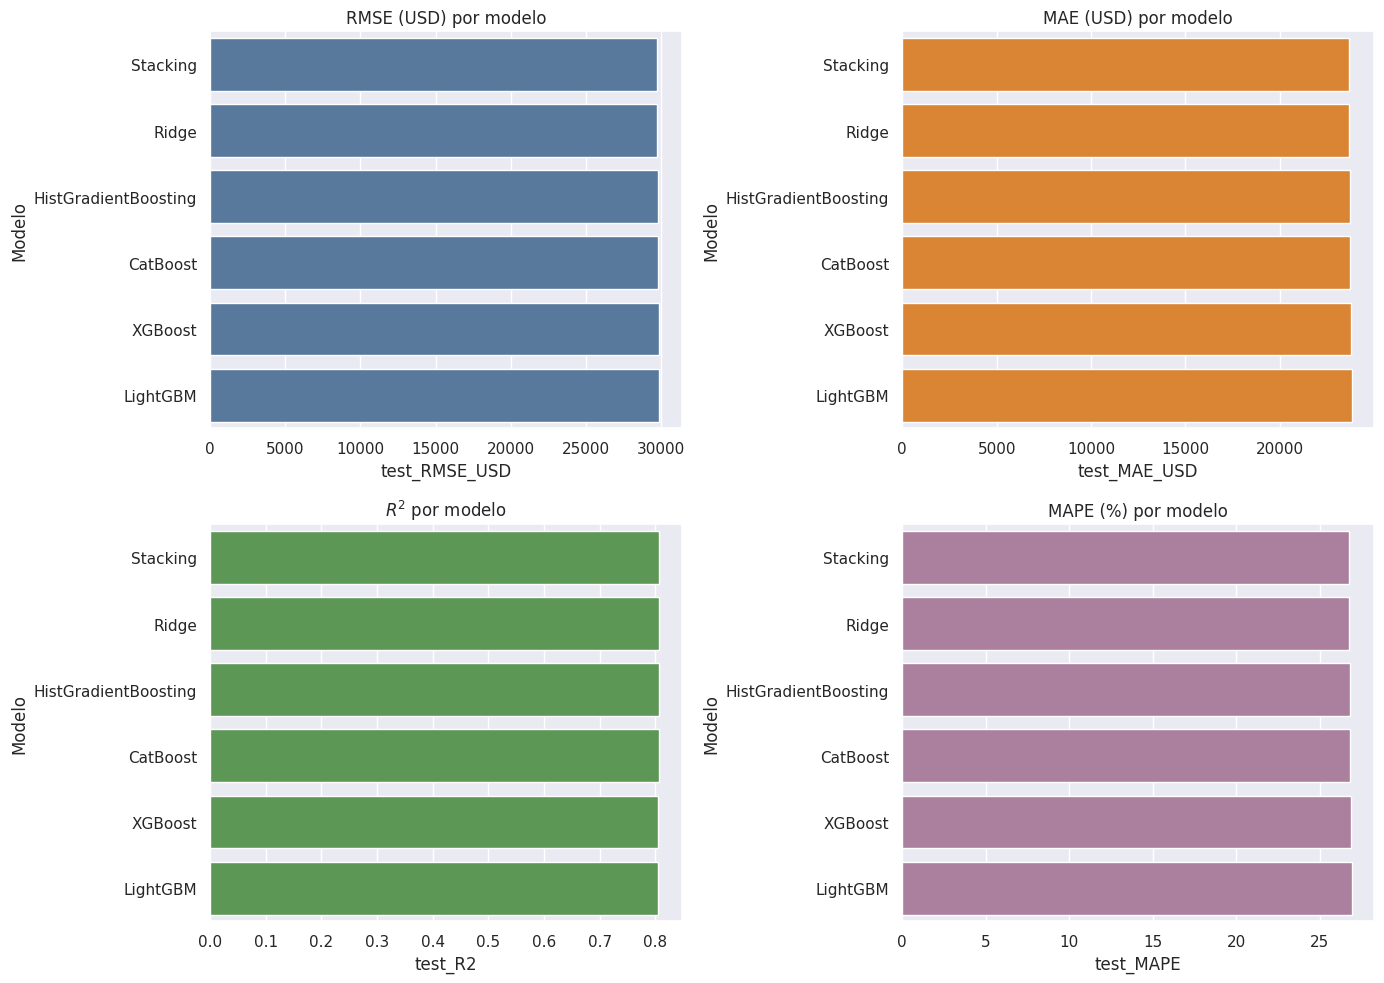

In [28]:
# Comparativa de métricas por modelo
if 'final_df' in globals():
    fig_dir = 'figures'
    os.makedirs(fig_dir, exist_ok=True)
    metrics_cols = ['test_RMSE_USD', 'test_MAE_USD', 'test_R2', 'test_MAPE']
    plot_df = final_df[['Modelo'] + metrics_cols].copy()
    plot_df = plot_df.sort_values('test_RMSE_USD')
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    sns.barplot(data=plot_df, x='test_RMSE_USD', y='Modelo', ax=axes[0, 0], color='#4C78A8')
    axes[0, 0].set_title('RMSE (USD) por modelo')
    sns.barplot(data=plot_df, x='test_MAE_USD', y='Modelo', ax=axes[0, 1], color='#F58518')
    axes[0, 1].set_title('MAE (USD) por modelo')
    sns.barplot(data=plot_df, x='test_R2', y='Modelo', ax=axes[1, 0], color='#54A24B')
    axes[1, 0].set_title('$R^2$ por modelo')
    sns.barplot(data=plot_df, x='test_MAPE', y='Modelo', ax=axes[1, 1], color='#B279A2')
    axes[1, 1].set_title('MAPE (%) por modelo')
    plt.tight_layout()
    fig.savefig(os.path.join(fig_dir, 'fig_model_metrics.png'), dpi=300, bbox_inches='tight')
    plt.show()

In [29]:
# Error y calibración del mejor modelo
if 'final_df' in globals() and 'trained_pipelines' in globals():
    best_model_name = final_df.iloc[0]['Modelo']
    best_pipe = trained_pipelines[best_model_name]
    y_pred = best_pipe.predict(X_test)
    err_df = X_test.copy()
    err_df = err_df.assign(y_true=y_test.values, y_pred=y_pred)
    err_df['error'] = err_df['y_pred'] - err_df['y_true']
    err_df['abs_error'] = err_df['error'].abs()
    err_df['y_true_usd'] = np.expm1(err_df['y_true'])
    err_df['y_pred_usd'] = np.expm1(err_df['y_pred'])
    err_df['error_usd'] = err_df['y_pred_usd'] - err_df['y_true_usd']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].scatter(err_df['y_true_usd'], err_df['y_pred_usd'], alpha=0.2, s=8)
    lims = [err_df['y_true_usd'].min(), err_df['y_true_usd'].max()]
    axes[0].plot(lims, lims, 'r--', lw=2)
    axes[0].set_title(f'Real vs Predicho (USD) - {best_model_name}')
    axes[0].set_xlabel('Salario real (USD)')
    axes[0].set_ylabel('Salario predicho (USD)')
    sns.histplot(err_df['error'], bins=50, ax=axes[1], color='#4C78A8')
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title('Distribución de errores (log)')
    axes[1].set_xlabel('Error (log)')
    sns.histplot(err_df['error_usd'], bins=50, ax=axes[2], color='#F58518')
    axes[2].axvline(0, color='red', linestyle='--')
    axes[2].set_title('Distribución de errores (USD)')
    axes[2].set_xlabel('Error (USD)')
    plt.tight_layout()
    plt.show()

Batches:  49%|████▉     | 615/1250 [00:02<00:02, 214.18it/s]


KeyboardInterrupt: 

In [14]:
# Sesgos por grupo: género, región, educación
def group_metrics(df_group, y_true_col='y_true', y_pred_col='y_pred'):
    y_true = df_group[y_true_col].values
    y_pred = df_group[y_pred_col].values
    return pd.Series({
        'count': len(df_group),
        'MAE_log': mean_absolute_error(y_true, y_pred),
        'RMSE_log': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    })

if 'final_df' in globals() and 'trained_pipelines' in globals():
    fig_dir = 'figures'
    os.makedirs(fig_dir, exist_ok=True)
    best_model_name = final_df.iloc[0]['Modelo']
    best_pipe = trained_pipelines[best_model_name]
    y_pred = best_pipe.predict(X_test)
    bias_df = X_test.copy()
    bias_df = bias_df.assign(y_true=y_test.values, y_pred=y_pred)
    for col in ['gender', 'region', 'education_level']:
        if col in bias_df.columns:
            group_df = bias_df.groupby(col).apply(group_metrics).sort_values('RMSE_log')
            display(group_df)
            plt.figure(figsize=(8, 4))
            sns.barplot(x=group_df['RMSE_log'], y=group_df.index, color='#4C78A8')
            plt.title(f'RMSE (log) por {col} - {best_model_name}')
            plt.xlabel('RMSE (log)')
            plt.tight_layout()
            plt.savefig(os.path.join(fig_dir, f'fig_bias_{col}.png'), dpi=300, bbox_inches='tight')
            plt.show()

## 15) Narrativa de resultados (plantilla para paper)
- **Modelo líder**: registrar el modelo con menor RMSE en test y su $R^2$.
- **Comparación**: discutir diferencias frente a baselines y modelos lineales.
- **Calibración**: describir el sesgo observado en `Real vs Predicho`.
- **Sesgos**: reportar brechas por género/educación/región usando las tablas y barras.
- **Conclusión**: destacar si embeddings semánticos mejoran la señal respecto a v3.